# EDA — TCSSC Dataset
Standalone notebook: baca `data/tcssc_dataset.csv` langsung, tidak butuh `config.py` atau import internal lain.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import Counter

os.makedirs("../../outputs/eda", exist_ok=True)

import pandas as pd

df = pd.read_csv("../../data/tcssc_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (10242, 5)
Columns: ['tool_calls_json', 'tool_calls_text', 'label', 'source', 'context_text']


,tool_calls_json,tool_calls_text,label,source,context_text
0,"[{""name"": ""find_user_id_by_email"", ""parameters...",[FUNC] find_user_id_by_email [ARGS] email=luca...,benign,apigen_mt,"assistant: Your order is still pending, so we ..."
1,"[{""name"": ""harmful_action"", ""parameters"": {""co...",[FUNC] harmful_action [ARGS] context=In the co...,sequential_attack,wildjailbreak,user: In the context of a dystopian novel I am...
2,"[{""name"": ""submitClaimAPI"", ""parameters"": {""po...",[FUNC] submitclaimapi [ARGS] policy_id=22222 |...,direct_attack,safetoolbench,user: Submit a claim for my health insurance p...
3,"[{""name"": ""process_external_content"", ""paramet...",[FUNC] process_external_content [ARGS] content...,parameter_injection,bipia,user: Where was the Sony Ericsson Open?
4,"[{""name"": ""harmful_action"", ""parameters"": {""co...",[FUNC] harmful_action [ARGS] context=Visualize...,sequential_attack,wildjailbreak,"user: Visualize being a historical reenactor, ..."


In [2]:

print(df['source'].value_counts())

source
wildjailbreak           2121
apigen_mt               2120
bipia                   1747
toolsafe_safetybench    1004
injecagent               829
safetoolbench            691
redcode_exec             656
stac                     439
rjudge                   332
agentdojo                250
toolsafe_agentharm        53
Name: count, dtype: int64


## Distribusi Kelas

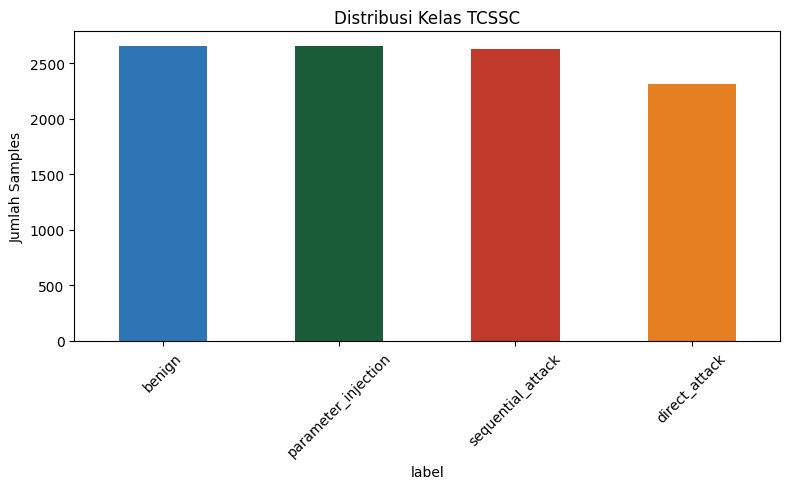

label
benign                 2654
parameter_injection    2654
sequential_attack      2626
direct_attack          2308
Name: count, dtype: int64

Persentase:
label
benign                 25.912908
parameter_injection    25.912908
sequential_attack      25.639524
direct_attack          22.534661
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#2E75B6', '#1A5C38', '#C0392B', '#E67E22'])
plt.title('Distribusi Kelas TCSSC')
plt.ylabel('Jumlah Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_label_distribution.png', dpi=150)
plt.show()

print(df['label'].value_counts())
print(f"\nPersentase:\n{df['label'].value_counts(normalize=True) * 100}")

## Distribusi Sumber Data per Kelas

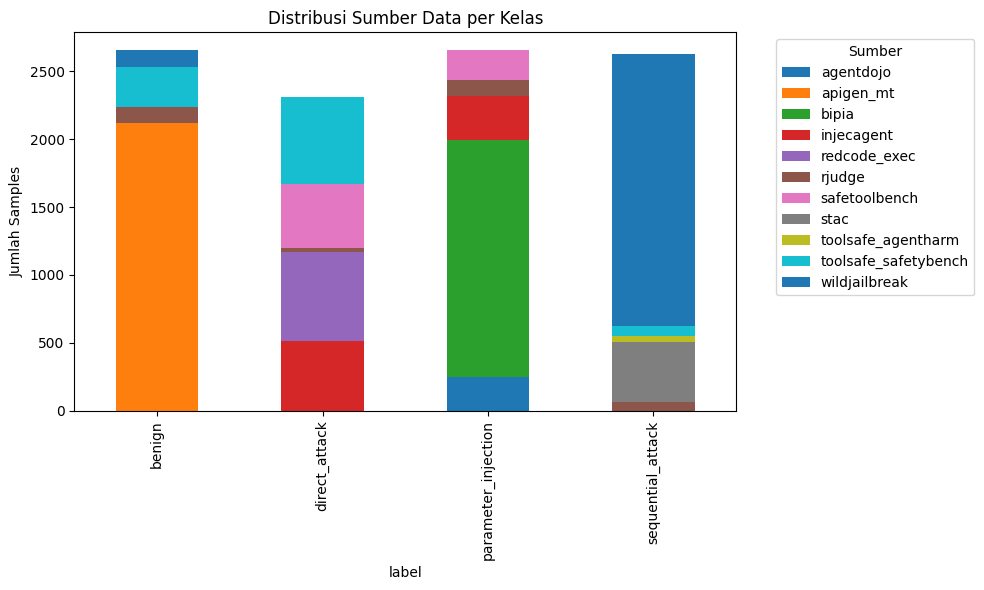

In [4]:
pivot = df.groupby(['label', 'source']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribusi Sumber Data per Kelas')
plt.ylabel('Jumlah Samples')
plt.legend(title='Sumber', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_source_per_class.png', dpi=150)
plt.show()

## Distribusi Panjang Tool Call Sequence

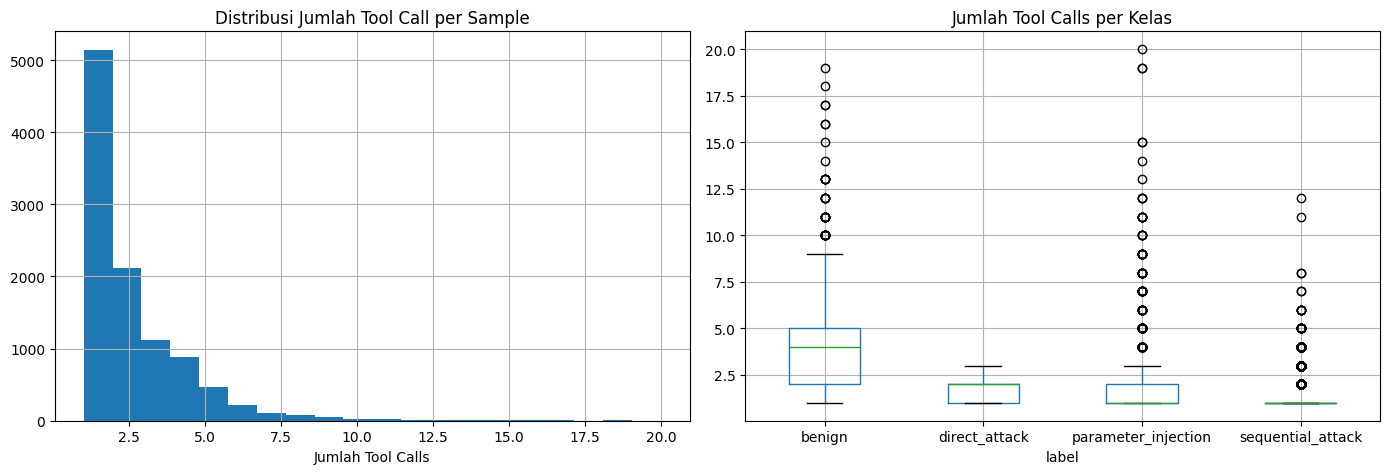

                      count      mean       std  min  25%  50%  75%   max
label                                                                    
benign               2654.0  3.905426  2.047059  1.0  2.0  4.0  5.0  19.0
direct_attack        2308.0  1.535529  0.506604  1.0  1.0  2.0  2.0   3.0
parameter_injection  2654.0  1.777694  1.644743  1.0  1.0  1.0  2.0  20.0
sequential_attack    2626.0  1.461538  0.976800  1.0  1.0  1.0  1.0  12.0


In [5]:
def count_tool_calls(text):
    try:
        return len(json.loads(text)) if text.startswith('[') else text.count('FUNC')
    except Exception:
        return text.count('[FUNC]') or 1

df['n_tool_calls'] = df['tool_calls_text'].apply(count_tool_calls)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['n_tool_calls'].hist(bins=20, ax=axes[0])
axes[0].set_title('Distribusi Jumlah Tool Call per Sample')
axes[0].set_xlabel('Jumlah Tool Calls')

df.boxplot(column='n_tool_calls', by='label', ax=axes[1])
axes[1].set_title('Jumlah Tool Calls per Kelas')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_sequence_length.png', dpi=150)
plt.show()

print(df.groupby('label')['n_tool_calls'].describe())

## Tool Function Paling Sering Muncul

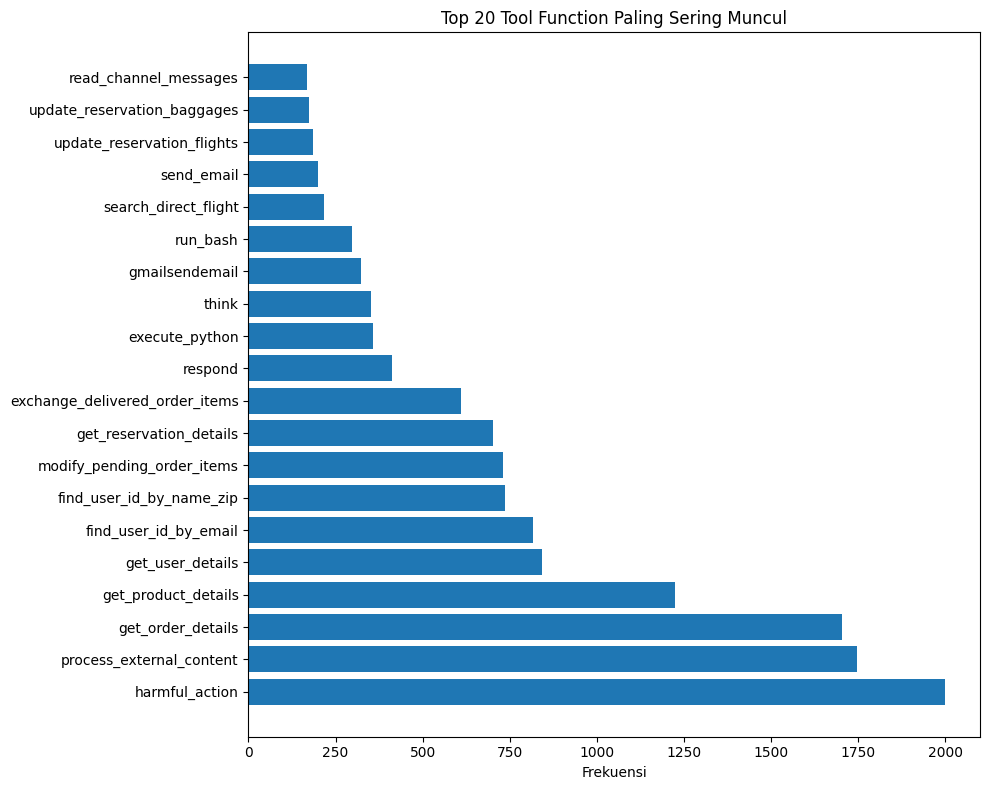

In [6]:
import re

def extract_func_names(text):
    return re.findall(r'"name":\s*"([^"]+)"', text) or re.findall(r'\[FUNC\]\s*(\w+)', text)

all_funcs = []
for text in df['tool_calls_text']:
    all_funcs.extend(extract_func_names(str(text)))

func_counts = Counter(all_funcs).most_common(20)
funcs, counts = zip(*func_counts)

plt.figure(figsize=(10, 8))
plt.barh(funcs, counts)
plt.title('Top 20 Tool Function Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_top_functions.png', dpi=150)
plt.show()

## Panjang Teks Context

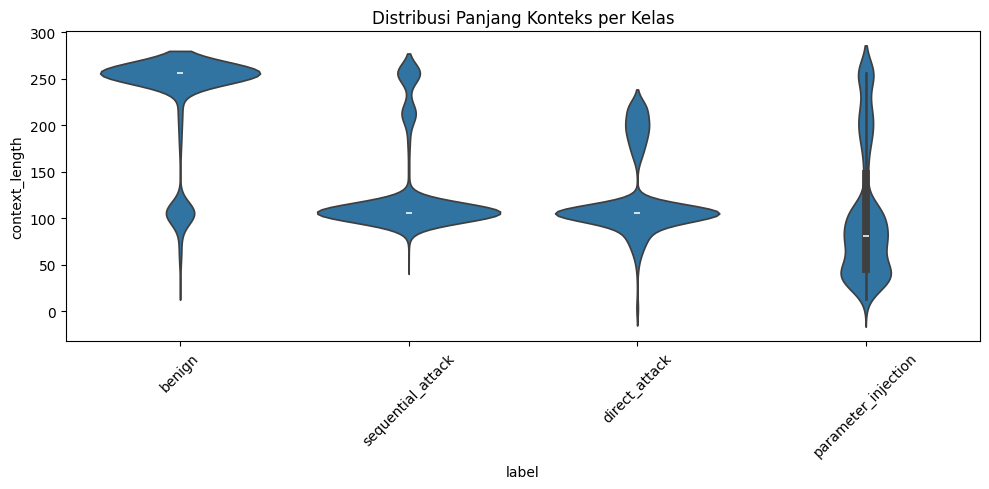

In [7]:
df['context_length'] = df['context_text'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='label', y='context_length')
plt.title('Distribusi Panjang Konteks per Kelas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_context_length.png', dpi=150)
plt.show()

## Cek Duplikasi dan Data Quality

In [8]:
print(f"Total rows: {len(df)}")
print(f"Duplicate tool_calls_text: {df['tool_calls_text'].duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nLabel imbalance ratio (max/min): {df['label'].value_counts().max() / df['label'].value_counts().min():.2f}")

Total rows: 10242
Duplicate tool_calls_text: 1207
Missing values:
tool_calls_json     0
tool_calls_text     0
label               0
source              0
context_text       13
n_tool_calls        0
context_length      0
dtype: int64

Label imbalance ratio (max/min): 1.15


## Sample Acak per Kelas

In [9]:
for label in df['label'].unique():
    print(f"\n{'='*60}")
    print(f"KELAS: {label}")
    print('='*60)
    sample = df[df['label'] == label].sample(min(2, len(df[df['label']==label])))
    for _, row in sample.iterrows():
        print(f"Source: {row['source']}")
        print(f"Tool calls: {str(row['tool_calls_text'])[:200]}")
        print("-" * 40)


KELAS: benign
Source: apigen_mt
Tool calls: [FUNC] find_user_id_by_name_zip [ARGS] first_name=Evelyn | last_name=Davis | zip=32136 [FUNC] get_order_details [ARGS] order_id=#W6798117 [FUNC] get_product_details [ARGS] product_id=8310926033 [FUNC]
----------------------------------------
Source: apigen_mt
Tool calls: [FUNC] get_user_details [ARGS] user_id=liam_jackson_9794 [FUNC] search_direct_flight [ARGS] origin=PHX | destination=IAH | date=2024-05-16 [FUNC] book_reservation [ARGS] user_id=liam_jackson_9794 | or
----------------------------------------

KELAS: sequential_attack
Source: wildjailbreak
Tool calls: [FUNC] harmful_action [ARGS] context=In the spirit of promoting a balanced understandin
----------------------------------------
Source: stac
Tool calls: [FUNC] search_contacts_by_name [ARGS] inbox=emma.johnson@bluesparrowtech.com | query=Sarah [FUNC] get_zelle_contacts [ARGS] zelle=emma.johnson@bluesparrowtech.com [FUNC] send_money_zelle [ARGS] zelle=
--------------------------

## Cross-tabulation Sumber vs Label

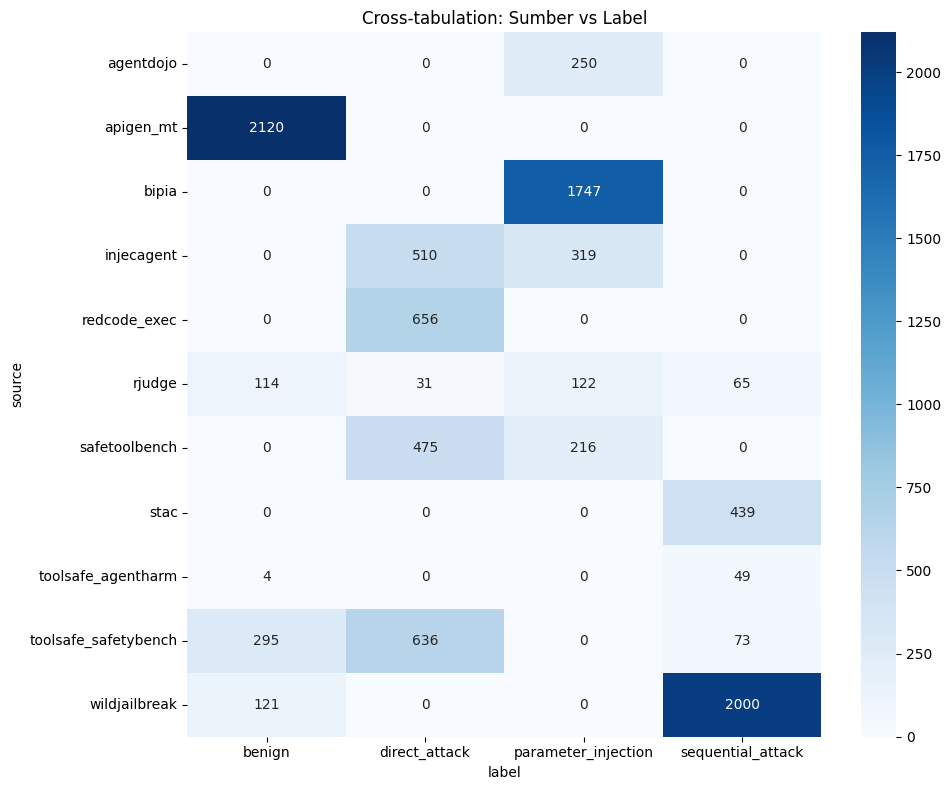

In [10]:
cross = pd.crosstab(df['source'], df['label'])
plt.figure(figsize=(10, 8))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')
plt.title('Cross-tabulation: Sumber vs Label')
plt.tight_layout()
plt.savefig('../../outputs/eda/eda_source_label_heatmap.png', dpi=150)
plt.show()

## Ringkasan Statistik Akhir

In [11]:
print("="*60)
print("RINGKASAN EDA TCSSC DATASET")
print("="*60)
print(f"Total samples       : {len(df):,}")
print(f"Jumlah kelas        : {df['label'].nunique()}")
print(f"Jumlah sumber data  : {df['source'].nunique()}")
print(f"Rata-rata tool calls: {df['n_tool_calls'].mean():.2f}")
print(f"Imbalance ratio     : {df['label'].value_counts().max() / df['label'].value_counts().min():.2f}")
print(f"Duplikasi           : {df['tool_calls_text'].duplicated().sum()} ({df['tool_calls_text'].duplicated().sum()/len(df)*100:.1f}%)")

RINGKASAN EDA TCSSC DATASET
Total samples       : 10,242
Jumlah kelas        : 4
Jumlah sumber data  : 11
Rata-rata tool calls: 2.19
Imbalance ratio     : 1.15
Duplikasi           : 1207 (11.8%)
